In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df_train = pd.read_csv('data/titanic/train.csv')
df_test = pd.read_csv('data/titanic/test.csv')
df_result = pd.read_csv('data/titanic/gender_submission.csv')



## [Dataset Titanic](https://www.kaggle.com/competitions/titanic/code)

In [2]:
df_test = pd.merge(df_test, df_result, how= 'left', on= 'PassengerId')

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
 11  Survived     418 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 56.1 KB


In [5]:
df_result.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


In [6]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df_train['Cabin'].unique()

<ArrowStringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [8]:
df_train['letter'] = df_train['Cabin'].str[0]

In [9]:
df_train['letter'] = df_train['letter'].fillna('U')
df_train['letter'].unique()



<ArrowStringArray>
['U', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str

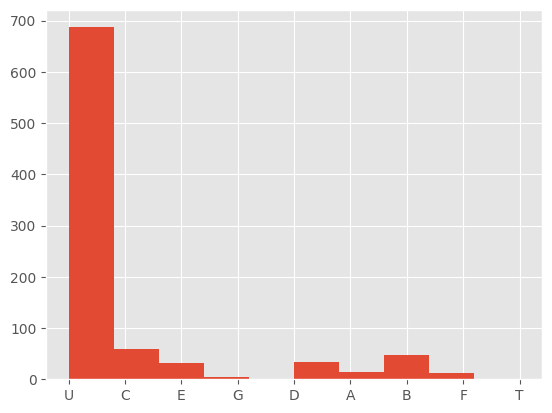

In [10]:
df_train['letter'].hist()
plt.show()

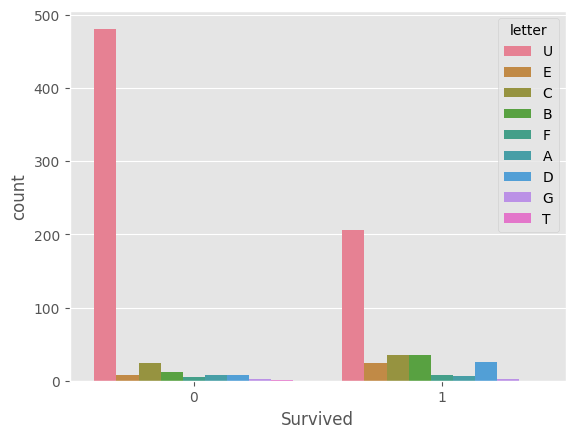

In [11]:
sns.countplot(df_train, hue = 'letter', x = 'Survived')

plt.show()

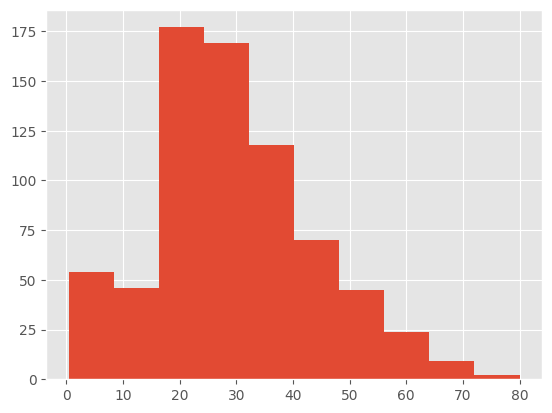

In [12]:
df_train['Age'].hist()
plt.show()

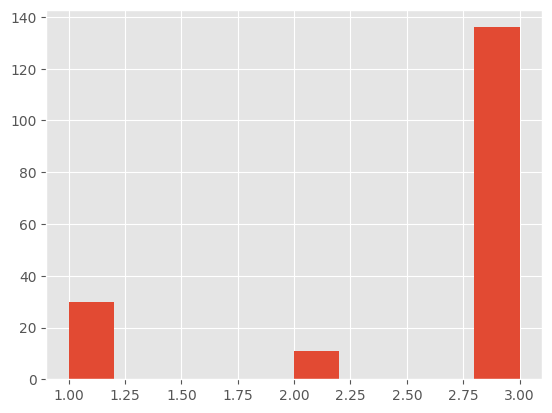

In [13]:
df = df_train
df[df['Age'].isnull()]['Pclass'].hist()
plt.show()

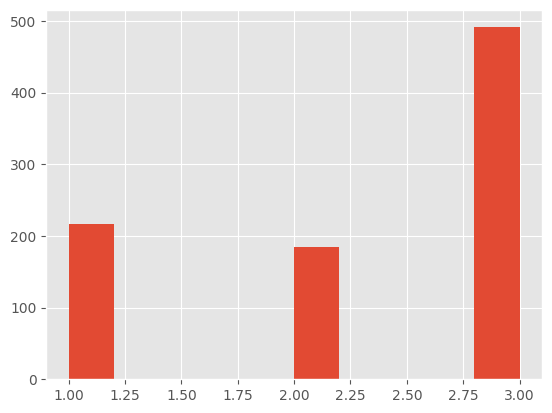

In [14]:
df['Pclass'].hist()
plt.show()

In [15]:
# Compare proportions
print("Unknown age group:")
print(df[df['Age'].isnull()]['Parch'].value_counts(normalize=True))

print("\nKnown age group:")
print(df[df['Age'].notnull()]['Parch'].value_counts(normalize=True))

Unknown age group:
Parch
0    0.887006
2    0.067797
1    0.045198
Name: proportion, dtype: float64

Known age group:
Parch
0    0.729692
1    0.154062
2    0.095238
5    0.007003
3    0.007003
4    0.005602
6    0.001401
Name: proportion, dtype: float64


In [16]:
# 1. Pclass distribution
print(df[df['Age'].isnull()]['Pclass'].value_counts(normalize=True))
print(df[df['Age'].notnull()]['Pclass'].value_counts(normalize=True))

# 2. SibSp distribution
print(df[df['Age'].isnull()]['SibSp'].value_counts(normalize=True))
print(df[df['Age'].notnull()]['SibSp'].value_counts(normalize=True))

# 3. Fare
print(df[df['Age'].isnull()]['Fare'].median())
print(df[df['Age'].notnull()]['Fare'].median())

Pclass
3    0.768362
1    0.169492
2    0.062147
Name: proportion, dtype: float64
Pclass
3    0.497199
1    0.260504
2    0.242297
Name: proportion, dtype: float64
SibSp
0    0.774011
1    0.146893
8    0.039548
3    0.022599
2    0.016949
Name: proportion, dtype: float64
SibSp
0    0.659664
1    0.256303
2    0.035014
4    0.025210
3    0.016807
5    0.007003
Name: proportion, dtype: float64
8.05
15.7417


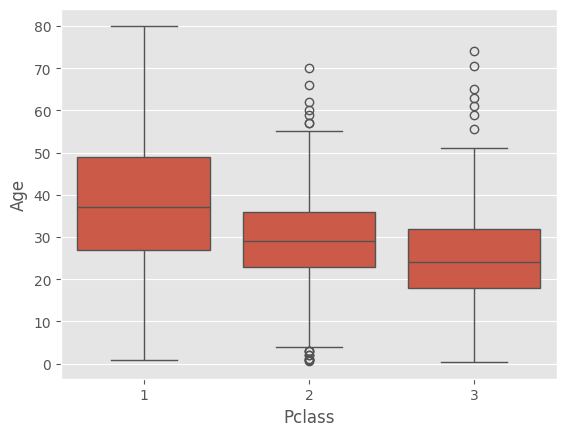

In [17]:
sns.boxplot(df, x = 'Pclass', y = 'Age')
plt.show()

In [18]:
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)

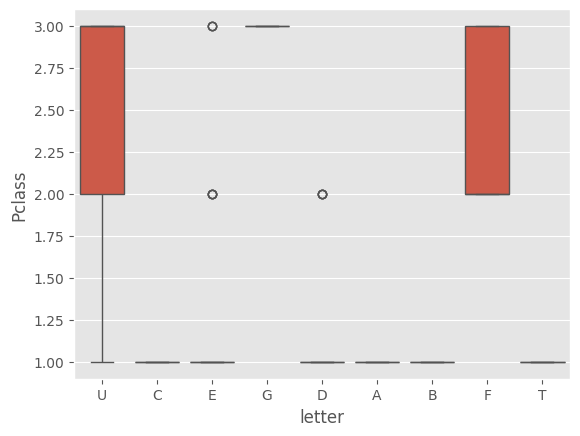

In [19]:
sns.boxplot(df, y = 'Pclass', x = 'letter')
plt.show()

In [20]:
df = df.dropna(subset = ['Embarked'])

In [21]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Survived         0
dtype: int64

In [22]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
print(df['Title'].value_counts())

Title
Mr              517
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [23]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
letter           0
Title            0
dtype: int64

In [24]:
df.info()


<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    str    
 11  Embarked     889 non-null    str    
 12  letter       889 non-null    str    
 13  Title        889 non-null    str    
dtypes: float64(2), int64(5), str(7)
memory usage: 143.0 KB


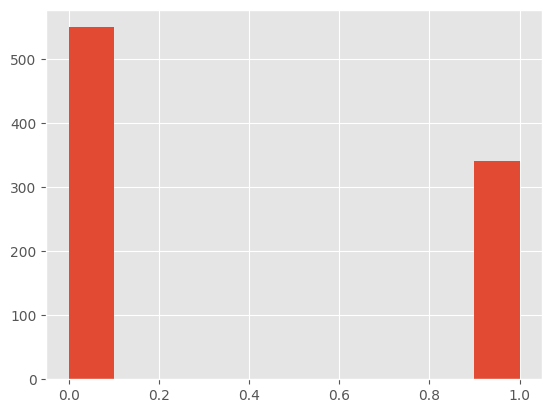

In [25]:
df['Survived'].hist()
plt.show()

In [26]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value= -1)

df[['Embarked', 'Cabin_Letter', 'Title']] = oe.fit_transform(
    df[['Embarked','letter', "Title"]]
)

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   889 non-null    int64  
 1   Survived      889 non-null    int64  
 2   Pclass        889 non-null    int64  
 3   Name          889 non-null    str    
 4   Sex           889 non-null    str    
 5   Age           889 non-null    float64
 6   SibSp         889 non-null    int64  
 7   Parch         889 non-null    int64  
 8   Ticket        889 non-null    str    
 9   Fare          889 non-null    float64
 10  Cabin         202 non-null    str    
 11  Embarked      889 non-null    float64
 12  letter        889 non-null    str    
 13  Title         889 non-null    float64
 14  Cabin_Letter  889 non-null    float64
dtypes: float64(5), int64(5), str(5)
memory usage: 146.6 KB


In [28]:
df['is_Male'] = (df['Sex'] == 'male').astype(int)

In [29]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'letter', 'Title',
       'Cabin_Letter', 'is_Male'],
      dtype='str')

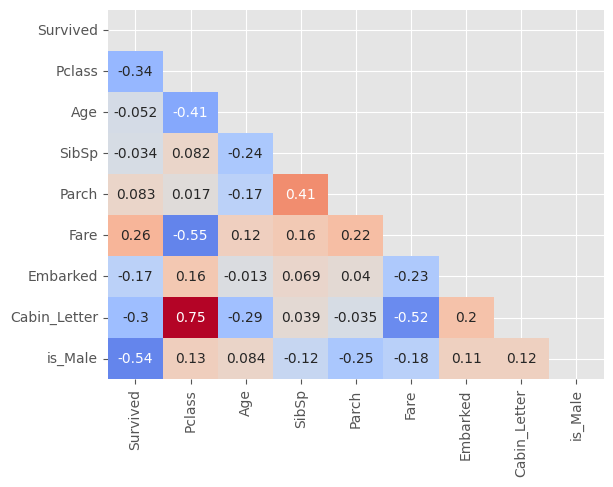

In [30]:
feature = [
    'Pclass', 'Age', 'SibSp', 'Parch', 
    # 'Title',
       'Fare', 'Embarked', 'Cabin_Letter', 'is_Male'
]

target = ['Survived']


matrix = df[target + feature].corr()

mask = np.triu(np.ones_like(matrix, dtype= bool))

sns.heatmap(matrix, mask = mask, cmap = 'coolwarm',
            center = 0, annot = True, cbar =False)

plt.show()

In [31]:
df_test['Title'] = df_test['Name'].str.extract(r',\s*([^\.]+)\.')

df_test['letter'] = df_test['Cabin'].fillna('U').str[0]
df_test['Age'] = df_test.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)

df_test[['Embarked', 'Cabin_Letter', 'Title']] = oe.transform(
    df_test[['Embarked','letter', 'Title']])

    
df_test = df_test.dropna(subset= ['Fare'])

df_test['is_Male'] = (df_test['Sex'] == 'male').astype(int)
df_test.isnull().sum()






PassengerId       0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin           326
Embarked          0
Survived          0
Title             0
letter            0
Cabin_Letter      0
is_Male           0
dtype: int64

In [32]:
from sklearn.model_selection import train_test_split

X = df[feature].copy()
y = df[target].copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=8)

# Keep X_test for final Kaggle submission only
X_test = df_test[feature].copy()

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix


models = {
    'xgb' : XGBClassifier(
    n_estimators = 200,
    random_state = 8
),
    'base' : Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
]),
    'gradient' : GradientBoostingClassifier(
    n_estimators= 200,
    random_state= 8
)
    
}

for name, model in models.items():
    print(f'Training {name}')
    model.fit(X_train, y_train.values.ravel())





Training xgb
Training base
Training gradient


Model xgb
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       108
           1       0.74      0.79      0.76        70

    accuracy                           0.81       178
   macro avg       0.80      0.80      0.80       178
weighted avg       0.81      0.81      0.81       178

Model base
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       108
           1       0.76      0.80      0.78        70

    accuracy                           0.82       178
   macro avg       0.81      0.82      0.81       178
weighted avg       0.82      0.82      0.82       178

Model gradient
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       108
           1       0.77      0.76      0.76        70

    accuracy                           0.81       178
   macro avg       0.81      0.80      0.81       178
weighted avg       0.81      0.81     

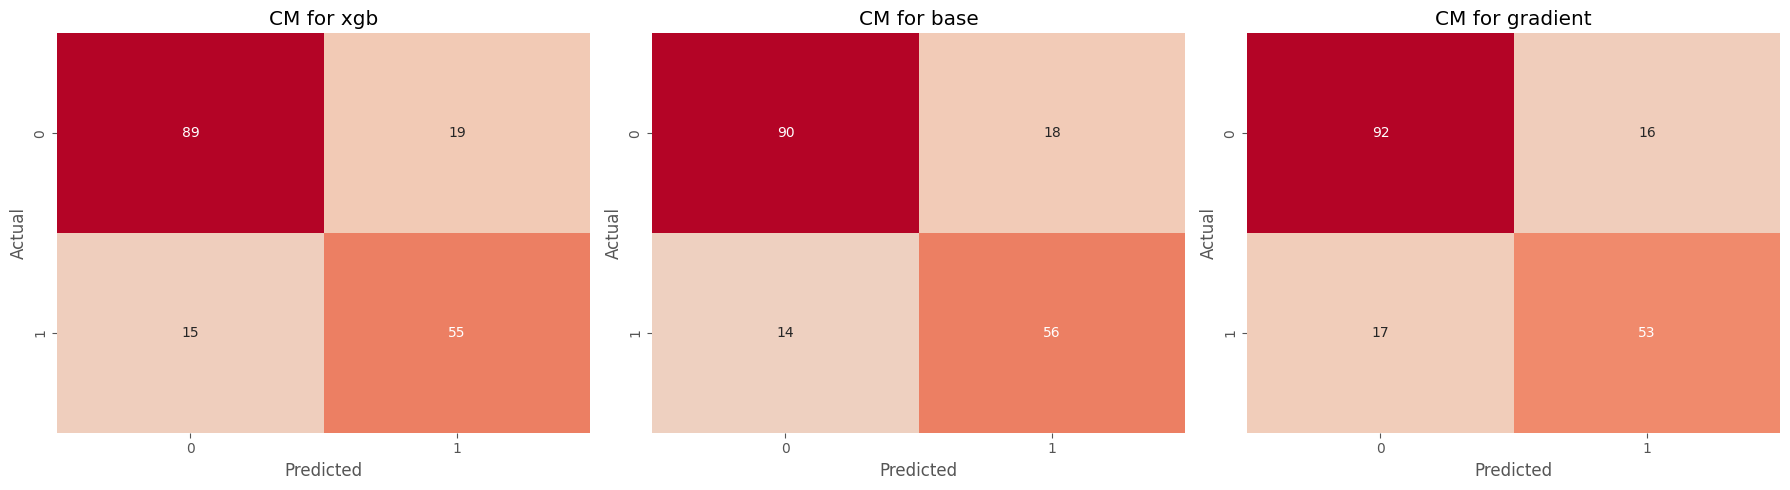

In [35]:
plt.figure(figsize=(18, 5))

for count, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_val)
    print(f'Model {name}')
    print(classification_report(y_true= y_val, y_pred= y_pred))

    cm = confusion_matrix(y_true= y_val, y_pred= y_pred)
    plt.subplot(1, 3, count + 1)
    sns.heatmap(cm, cmap = 'coolwarm', fmt = 'd', 
                center = 0, annot = True, cbar =False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'CM for {name}')

plt.tight_layout()
plt.show()

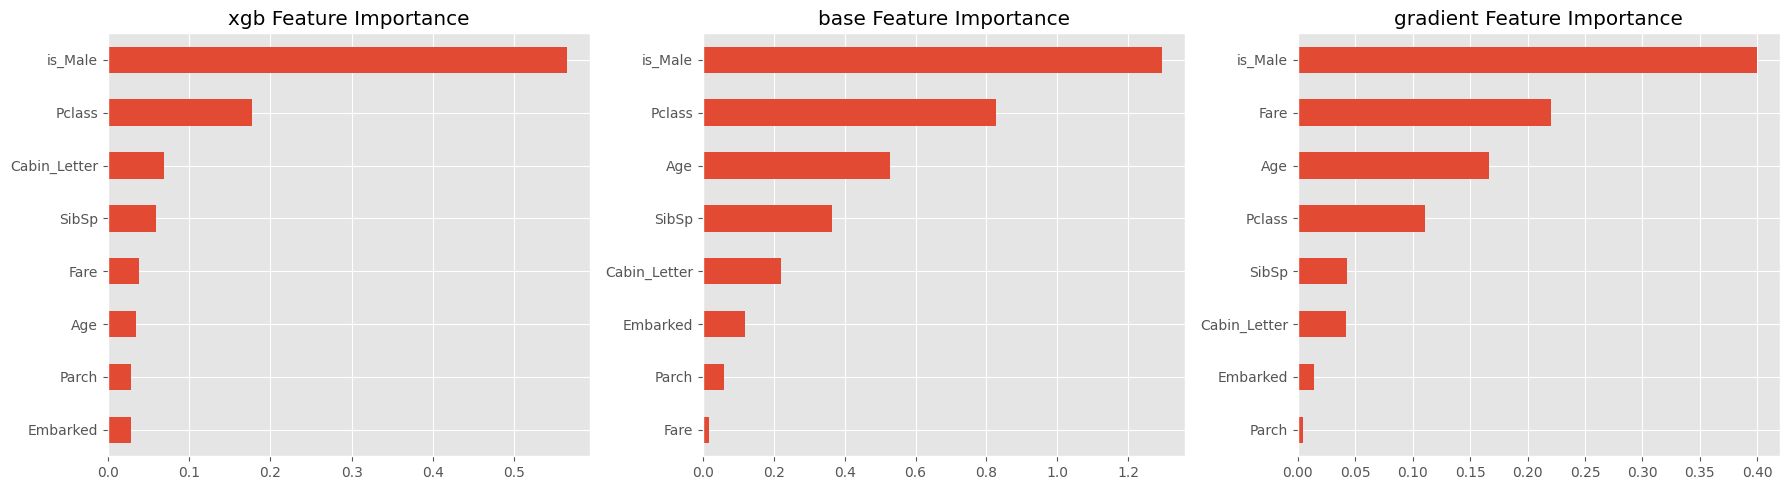

In [36]:
fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    if name == 'base':
        lr_model = model.named_steps['lr']
        importance = pd.Series(lr_model.coef_[0], index=X_train.columns).abs()
    else:
        importance = pd.Series(model.feature_importances_, index=X_train.columns)
    
    importance.sort_values().plot(kind='barh', ax=ax, title=f'{name} Feature Importance')

plt.tight_layout()
plt.show()

Model xgb
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       108
           1       0.78      0.80      0.79        70

    accuracy                           0.83       178
   macro avg       0.82      0.83      0.82       178
weighted avg       0.83      0.83      0.83       178



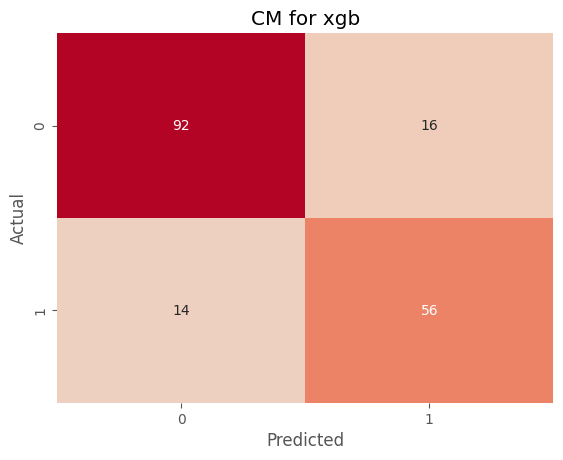

In [41]:
from sklearn.ensemble import StackingClassifier

ensemble = StackingClassifier(estimators=[
    ('xgb', models['xgb']),
    ('base', models['base']),
    ('gradient', models['gradient'])
], final_estimator=LogisticRegression()) 


ensemble.fit(X_train, y_train.values.ravel())

y_pred = ensemble.predict(X_val)
print(f'Model {name}')
print(classification_report(y_true= y_val, y_pred= y_pred))
cm = confusion_matrix(y_true= y_val, y_pred= y_pred)


sns.heatmap(cm, cmap = 'coolwarm', fmt = 'd', 
            center = 0, annot = True, cbar =False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'CM for {name}')
plt.show()
